In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import folium
from folium import LayerControl

# 1) Chargement des jeux de données train/test déjà générés

In [79]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")

X_train_sans_scaler = pd.read_csv('X_train_sans_scaler.csv', index_col="idannonce")
X_test_sans_scaler = pd.read_csv('X_test_sans_scaler.csv', index_col="idannonce")

y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

### On enleve le prix au m2 par rapport aux travaux précédents (et on renomme la colonne de target_encoding)

In [80]:
X_train = X_train.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test = X_test.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_train_sans_scaler = X_train_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test_sans_scaler = X_test_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)

### On reprend les features selectionnées

In [4]:
selected_dict = joblib.load("selected_dict_12102026.joblib")

In [5]:
#si l'on regarde l'intersection entre les features sélectionnées par la PCA et les features sélectionnées par la lr:
selected = set(selected_dict['lr'][:47]).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['surface_terrain',
 'annee_2020',
 'surface',
 'logement_neuf',
 'annonce_exclusive_Oui',
 'expo_sud',
 'ascenseur',
 'dpe_B',
 'categorie_annonceur_a',
 'avg_commune_type_pieces',
 'nb_etages',
 'eau',
 'UU2010',
 'Longitude_scaled',
 'categorie_annonceur_cm',
 'typedetransaction_vp',
 'nb_logements_copro',
 'dpe_A',
 'nb_toilettes',
 'balcon',
 'bain',
 'annee_2023',
 'chauffage_mode_individuel',
 'dpeC',
 'nb_pieces']

In [6]:
len(selected)

25

## On découpe le jeu de données pour chercher des modèles différents

#### Découpage X et y par type de bien

In [7]:
X_train_appartements = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_train_sans_scaler_appartements = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
y_train_appartements = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_test_appartements = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
X_test_sans_scaler_appartements = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
y_test_appartements = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]

X_train_maisons = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_train_sans_scaler_maisons = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
y_train_maisons = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_test_maisons = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
X_test_sans_scaler_maisons = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
y_test_maisons = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]

In [44]:
print(X_train.shape)
print(y_train.shape)
print(X_train_appartements.shape)
print(X_train_sans_scaler_appartements.shape)
print(y_train_appartements.shape)
print(X_train_maisons.shape)
print(X_train_sans_scaler_maisons.shape)
print(y_train_maisons.shape)

(20569, 93)
(20569, 1)
(10192, 93)
(10192, 93)
(10192, 1)
(10377, 93)
(10377, 93)
(10377, 1)


In [45]:
print(X_test.shape)
print(y_test.shape)
print(X_test_appartements.shape)
print(X_test_sans_scaler_appartements.shape)
print(y_test_appartements.shape)
print(X_test_maisons.shape)
print(X_test_sans_scaler_maisons.shape)
print(y_test_maisons.shape)

(5127, 93)
(5127, 1)
(2502, 93)
(2502, 93)
(2502, 1)
(2625, 93)
(2625, 93)
(2625, 1)


# 2) XGBoost

In [46]:
from xgboost import XGBRegressor

xgb_all = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_all.fit(X_train[selected], y_train)

y_pred_xgb = xgb_all.predict(X_test[selected])

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R2   : {r2_xgb:.4f}")



MAE  : 50650.52
RMSE : 79780.58
R2   : 0.7487


#### XGBoost Appartements

In [47]:
xgb_appartements = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_appartements.fit(X_train_appartements[selected], y_train_appartements)

y_pred_xgb_appartements = xgb_appartements.predict(X_test_appartements[selected])

mae_xgb_appartements = mean_absolute_error(y_test_appartements, y_pred_xgb_appartements)
rmse_xgb_appartements = np.sqrt(mean_squared_error(y_test_appartements, y_pred_xgb_appartements))
r2_xgb_appartements = r2_score(y_test_appartements, y_pred_xgb_appartements)

print(f"MAE  : {mae_xgb_appartements:.2f}")
print(f"RMSE : {rmse_xgb_appartements:.2f}")
print(f"R2   : {r2_xgb_appartements:.4f}")

MAE  : 34697.57
RMSE : 52450.14
R2   : 0.7323


#### XGBoost Maisons

In [48]:
xgb_maisons = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_maisons.fit(X_train_maisons[selected], y_train_maisons)

y_pred_xgb_maisons = xgb_maisons.predict(X_test_maisons[selected])

mae_xgb_maisons = mean_absolute_error(y_test_maisons, y_pred_xgb_maisons)
rmse_xgb_maisons = np.sqrt(mean_squared_error(y_test_maisons, y_pred_xgb_maisons))
r2_xgb_maisons = r2_score(y_test_maisons, y_pred_xgb_maisons)

print(f"MAE  : {mae_xgb_maisons:.2f}")
print(f"RMSE : {rmse_xgb_maisons:.2f}")
print(f"R2   : {r2_xgb_maisons:.4f}")

MAE  : 62347.50
RMSE : 96346.94
R2   : 0.6660


# 3) RandomForrest

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=5)
rf.fit(X_train[selected],y_train)

y_pred_rf = rf.predict(X_test[selected])

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R2   : {r2_rf:.4f}")

/home/yhov7445/workspace/2025_Parcours_DS/projet/Projet_DS2025/venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 66517.30
RMSE : 101302.93
R2   : 0.5948


#### RandomForrest Appartements

In [50]:
rf_appartements = RandomForestRegressor(n_estimators=100, max_depth=5)

rf_appartements.fit(X_train_appartements[selected], y_train_appartements)

y_pred_rf_appartements = rf_appartements.predict(X_test_appartements[selected])

mae_rf_appartements = mean_absolute_error(y_test_appartements, y_pred_rf_appartements)
rmse_rf_appartements = np.sqrt(mean_squared_error(y_test_appartements, y_pred_rf_appartements))
r2_rf_appartements = r2_score(y_test_appartements, y_pred_rf_appartements)

print(f"MAE  : {mae_rf_appartements:.2f}")
print(f"RMSE : {rmse_rf_appartements:.2f}")
print(f"R2   : {r2_rf_appartements:.4f}")

/home/yhov7445/workspace/2025_Parcours_DS/projet/Projet_DS2025/venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 47015.75
RMSE : 66830.98
R2   : 0.5654


#### RandomForrest Maisons

In [51]:
rf_maisons = RandomForestRegressor(n_estimators=200, max_depth=10)

rf_maisons.fit(X_train_maisons[selected], y_train_maisons)

y_pred_rf_maisons = rf_maisons.predict(X_test_maisons[selected])

mae_rf_maisons = mean_absolute_error(y_test_maisons, y_pred_rf_maisons)
rmse_rf_maisons = np.sqrt(mean_squared_error(y_test_maisons, y_pred_rf_maisons))
r2_rf_maisons = r2_score(y_test_maisons, y_pred_rf_maisons)

print(f"MAE  : {mae_rf_maisons:.2f}")
print(f"RMSE : {rmse_rf_maisons:.2f}")
print(f"R2   : {r2_rf_maisons:.4f}")


/home/yhov7445/workspace/2025_Parcours_DS/projet/Projet_DS2025/venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 68689.46
RMSE : 106312.81
R2   : 0.5933


## Pour la suite, on va garder XGBoost qui a de meilleurs résultats

# 4)  Etude sur une séparation possible du modèe

## Score du modèle global sur les appartements 

In [52]:
y_pred_xgb_ = xgb_all.predict(X_test_appartements[selected])

print(f"MAE  : {mean_absolute_error(y_test_appartements, y_pred_xgb_):.2f}")
print(f"RMSE : {mean_squared_error(y_test_appartements, y_pred_xgb_):.2f}")
print(f"R2   : {r2_score(y_test_appartements, y_pred_xgb_):.4f}")

MAE  : 36743.16
RMSE : 2983676416.00
R2   : 0.7097


## Score du modèle global sur les maisons 

In [53]:
y_pred_xgb_ = xgb_all.predict(X_test_maisons[selected])

print(f"MAE  : {mean_absolute_error(y_test_maisons, y_pred_xgb_):.2f}")
print(f"RMSE : {mean_squared_error(y_test_maisons, y_pred_xgb_):.2f}")
print(f"R2   : {r2_score(y_test_maisons, y_pred_xgb_):.4f}")

MAE  : 63906.23
RMSE : 9587766272.00
R2   : 0.6550


# Question: comment interpréter cette difference avec le score du modèle global sur l'ensemble du jeu de test ???

## Focus sur les maisons en fonction du nombre de pièces

# Scores Model global et model maison sur les maisons en fonction du nombre de pièce

In [55]:
def score_nbpieces(nb):
    
    
    indexes_test = X_test_sans_scaler_maisons[X_test_sans_scaler_maisons['nb_pieces'] == nb].index
    print(f"Nombre d'echantillons de test: {len(indexes_test)}")
    if len(indexes_test) > 0:

        X_test_ = X_test_maisons.loc[indexes_test]
        y_test_ = y_test_maisons.loc[indexes_test]
        
        print(f"--Avec modèle entrainé sur les maisons de {nb} pièces")

        indexes_train = X_train_sans_scaler_maisons[X_train_sans_scaler_maisons['nb_pieces'] == nb].index
        print(f"Nombre d'echantillons de train: {len(indexes_train)}")
    
        X_train_ = X_train_maisons.loc[indexes_train]
        y_train_ = y_train_maisons.loc[indexes_train]
        
        xgb_ = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
        )
    
        xgb_.fit(X_train_[selected], y_train_)
        
        y_pred_xgb_ = xgb_.predict(X_test_[selected])
        
        print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
        print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
        print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")

        print("--Avec modèle global")

        y_pred_xgb_ = xgb_all.predict(X_test_[selected])
        
        print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
        print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
        print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
        
        print("--Avec modèle maison")

        y_pred_xgb_ = xgb_maisons.predict(X_test_[selected])
        
        print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
        print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
        print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
        
    else:
        print("Pas d echantillon de test corresondant pour faire le calcul de score")

In [56]:
for nb_focus in np.sort(X_train_sans_scaler_maisons['nb_pieces'].unique()):
    print(f"---- Resultats pour nb pieces: {nb_focus}:")
    score_nbpieces(nb_focus)


---- Resultats pour nb pieces: 1:
Nombre d'echantillons de test: 11
--Avec modèle entrainé sur les maisons de 1 pièces
Nombre d'echantillons de train: 33
MAE  : 42750.45
RMSE : 51622.11
R2   : 0.8492
--Avec modèle global
MAE  : 38144.23
RMSE : 48943.38
R2   : 0.8644
--Avec modèle maison
MAE  : 34791.91
RMSE : 43352.14
R2   : 0.8936
---- Resultats pour nb pieces: 2:
Nombre d'echantillons de test: 18
--Avec modèle entrainé sur les maisons de 2 pièces
Nombre d'echantillons de train: 71
MAE  : 38209.73
RMSE : 66363.88
R2   : -2.6977
--Avec modèle global
MAE  : 32968.08
RMSE : 55795.83
R2   : -1.6138
--Avec modèle maison
MAE  : 28405.72
RMSE : 48242.33
R2   : -0.9540
---- Resultats pour nb pieces: 3:
Nombre d'echantillons de test: 82
--Avec modèle entrainé sur les maisons de 3 pièces
Nombre d'echantillons de train: 359
MAE  : 47237.77
RMSE : 64544.26
R2   : 0.4885
--Avec modèle global
MAE  : 46523.99
RMSE : 64422.27
R2   : 0.4904
--Avec modèle maison
MAE  : 44485.62
RMSE : 62515.53
R2   : 0

## En essaynt de séparer le modèle en deux: maisons de 8 pièces ou moins et maisons au dessus de 8 pièces

In [57]:
seuil = 8

indexes_train = X_train_sans_scaler_maisons[X_train_sans_scaler_maisons['nb_pieces'] <= seuil].index
print(f"Nombre d'echantillons de train sous seuil: {len(indexes_train)}")

X_train_ = X_train_maisons.loc[indexes_train]
y_train_ = y_train_maisons.loc[indexes_train]

indexes_test = X_test_sans_scaler_maisons[X_test_sans_scaler_maisons['nb_pieces'] <= seuil].index
print(f"Nombre d'echantillons de test sous seuil: {len(indexes_test)}")
if len(indexes_test) > 0:

    X_test_ = X_test_maisons.loc[indexes_test]
    y_test_ = y_test_maisons.loc[indexes_test]

    xgb_sous_seuil = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
    )

    xgb_sous_seuil.fit(X_train_[selected], y_train_)
    
    y_pred_xgb_ = xgb_sous_seuil.predict(X_test_[selected])

    print(f"--Avec modèle limité à {seuil} pièces")
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")

    print("--Avec modèle global")

    y_pred_xgb_ = xgb_all.predict(X_test_[selected])
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
    
    print("--Avec modèle maison")

    y_pred_xgb_ = xgb_maisons.predict(X_test_[selected])
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
    
else:
    print("Pas d echantillon de test corresondant pour faire le calcul de score")


indexes_train = X_train_sans_scaler_maisons[X_train_sans_scaler_maisons['nb_pieces'] > seuil].index
print(f"Nombre d'echantillons de train au dessus du seuil: {len(indexes_train)}")

X_train_ = X_train_maisons.loc[indexes_train]
y_train_ = y_train_maisons.loc[indexes_train]

indexes_test = X_test_sans_scaler_maisons[X_test_sans_scaler_maisons['nb_pieces'] > seuil].index
print(f"Nombre d'echantillons de test au dessus du seuil: {len(indexes_test)}")
if len(indexes_test) > 0:

    X_test_ = X_test_maisons.loc[indexes_test]
    y_test_ = y_test_maisons.loc[indexes_test]

    xgb_au_dessus_seuil = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
    )

    xgb_au_dessus_seuil.fit(X_train_[selected], y_train_)
    
    y_pred_xgb_ = xgb_au_dessus_seuil.predict(X_test_[selected])

    print(f"--Avec modèle au dessu de {seuil} pièces")
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")

    print("--Avec modèle global")

    y_pred_xgb_ = xgb_all.predict(X_test_[selected])
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
    
    print("--Avec modèle maison")

    y_pred_xgb_ = xgb_maisons.predict(X_test_[selected])
    
    print(f"MAE  : { mean_absolute_error(y_test_, y_pred_xgb_):.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test_, y_pred_xgb_)):.2f}")
    print(f"R2   : {r2_score(y_test_, y_pred_xgb_):.4f}")
    
else:
    print("Pas d echantillon de test correspondant pour faire le calcul de score")  

Nombre d'echantillons de train sous seuil: 9874
Nombre d'echantillons de test sous seuil: 2501
--Avec modèle limité à 8 pièces
MAE  : 58545.88
RMSE : 88305.67
R2   : 0.6966
--Avec modèle global
MAE  : 60118.58
RMSE : 89150.53
R2   : 0.6908
--Avec modèle maison
MAE  : 58488.25
RMSE : 86813.15
R2   : 0.7068
Nombre d'echantillons de train au dessus du seuil: 503
Nombre d'echantillons de test au dessus du seuil: 124
--Avec modèle au dessu de 8 pièces
MAE  : 144393.64
RMSE : 212138.53
R2   : 0.2126
--Avec modèle global
MAE  : 140300.70
RMSE : 206553.85
R2   : 0.2535
--Avec modèle maison
MAE  : 140185.88
RMSE : 210956.50
R2   : 0.2214


## Il ne parait pas pertinent de distinguer donc un modèle au dessus d'un seuil

## Etude annexe: focus sur les biens de 2 pièces et scores sur différents modèles (entrainés sur jeu de train dépendnat du nombre de pièces)

In [24]:
nb_focus = 2
indexes_test = X_test_sans_scaler_maisons[X_test_sans_scaler_maisons['nb_pieces'] == nb_focus].index
print(f"Nombre d'echantillons de test: {len(indexes_test)}")
if len(indexes_test) > 0:
    for nb in np.sort(X_train_sans_scaler_maisons['nb_pieces'].unique()):
        # On regarde meme avec un modele entrainé sur un nb piièce < nb_focus
        print(f"---- Entrainement sur des enregistrementss jusqu'à {nb} pièce{'' if nb == 1 else 's'}:")
        indexes_train = X_train_sans_scaler_maisons[X_train_sans_scaler_maisons['nb_pieces'] <= nb].index
        print(f"Nombre d'echantillons de train: {len(indexes_train)}")
    
        X_train_ = X_train_maisons.loc[indexes_train]
        y_train_ = y_train_maisons.loc[indexes_train]
        
        
        print("-----Score obtenu sur les biens de {nb_focus} pièce{'' if nb_focus == 1 else 's'}:")

        X_test_ = X_test_maisons.loc[indexes_test]
        y_test_ = y_test_maisons.loc[indexes_test]

        xgb_ = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
        )
    
        xgb_.fit(X_train_[selected], y_train_)
        
        y_pred_xgb_ = xgb_.predict(X_test_[selected])
        
        
        mae_maisons_ = mean_absolute_error(y_test_, y_pred_xgb_)
        rmse_maisons_ = np.sqrt(mean_squared_error(y_test_, y_pred_xgb_))
        r2_maisons_ = r2_score(y_test_, y_pred_xgb_)
        
        print(f"MAE  : {mae_maisons_:.2f}")
        print(f"RMSE : {rmse_maisons_:.2f}")
        print(f"R2   : {r2_maisons_:.4f}")
else:
    print(f"Pas d echantillon de test corresondant au nombre de piece {nb_focus} pour faire le calcul de score")

Nombre d'echantillons de test: 18
---- Entrainement sur des enregistrementss jusqu'à 1 pièce:
Nombre d'echantillons de train: 33
-----Score obtenu sur les biens de {nb_focus} pièce{'' if nb_focus == 1 else 's'}:
MAE  : 66028.98
RMSE : 71554.08
R2   : -3.2986
---- Entrainement sur des enregistrementss jusqu'à 2 pièces:
Nombre d'echantillons de train: 104
-----Score obtenu sur les biens de {nb_focus} pièce{'' if nb_focus == 1 else 's'}:
MAE  : 34141.31
RMSE : 61922.77
R2   : -2.2193
---- Entrainement sur des enregistrementss jusqu'à 3 pièces:
Nombre d'echantillons de train: 463
-----Score obtenu sur les biens de {nb_focus} pièce{'' if nb_focus == 1 else 's'}:
MAE  : 31801.12
RMSE : 53281.46
R2   : -1.3835
---- Entrainement sur des enregistrementss jusqu'à 4 pièces:
Nombre d'echantillons de train: 2097
-----Score obtenu sur les biens de {nb_focus} pièce{'' if nb_focus == 1 else 's'}:
MAE  : 31533.93
RMSE : 52224.76
R2   : -1.2899
---- Entrainement sur des enregistrementss jusqu'à 5 pièces

# 5)  Catégoriser les prix de maisons

## On regarde d'abord la distribution des prix du jeu de données

In [9]:
y_train.describe()

,prix_bien
count,2.056900e+04
mean,2.700713e+05
std,1.600646e+05
min,1.076000e+03
25%,1.600000e+05
50%,2.420000e+05
75%,3.421800e+05
max,2.730000e+06


In [15]:
y_train

,prix_bien
idannonce,
ag681108-285757544,208300
ag680297-340567902,380000
hektor-girardi-pfastatt-2683,129000
orpi-1-054928E2CVGG,399000
ag671791-287402273,98000
...,...
ag440414-273408896,111000
ag681391-366397327,180000
orpi-1-054039E2F462,424800


In [10]:
import matplotlib.pyplot as plt

(array([3.741e+03, 8.401e+03, 5.456e+03, 1.848e+03, 6.590e+02, 2.600e+02,
        1.320e+02, 3.700e+01, 1.200e+01, 1.100e+01, 1.000e+00, 0.000e+00,
        3.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00]),
 array([1.0760000e+03, 1.3752220e+05, 2.7396840e+05, 4.1041460e+05,
        5.4686080e+05, 6.8330700e+05, 8.1975320e+05, 9.5619940e+05,
        1.0926456e+06, 1.2290918e+06, 1.3655380e+06, 1.5019842e+06,
        1.6384304e+06, 1.7748766e+06, 1.9113228e+06, 2.0477690e+06,
        2.1842152e+06, 2.3206614e+06, 2.4571076e+06, 2.5935538e+06,
        2.7300000e+06]),
 <BarContainer object of 20 artists>)

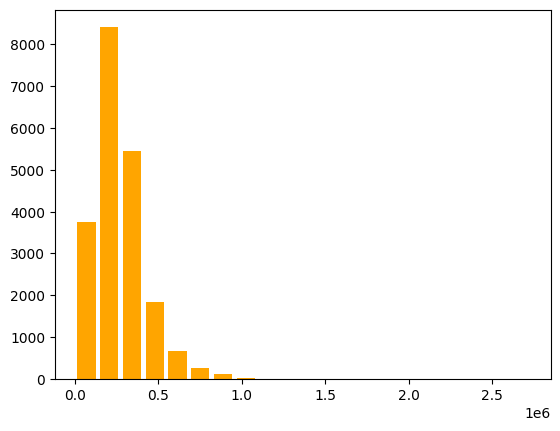

In [13]:
plt.hist(y_train,  bins=20, color='orange', rwidth=0.8)

### Pour rappel, le MAE est de 50650 euros (XGBoost Global) cela aurait été bien de faire des catégories de prix de moins de 50 000 euros (cpour assurer d'être meilleur que la régression) mais cela ferait trop de catégrories

(array([ 200., 1767., 2618., 3305., 3002., 2830., 2108., 1620., 1017.,
         680.,  331.,  319.,  202.,  157.,   99.,   87.,   63.,   54.,
          32.,   31.]),
 array([  1076. ,  50972.2, 100868.4, 150764.6, 200660.8, 250557. ,
        300453.2, 350349.4, 400245.6, 450141.8, 500038. , 549934.2,
        599830.4, 649726.6, 699622.8, 749519. , 799415.2, 849311.4,
        899207.6, 949103.8, 999000. ]),
 <BarContainer object of 20 artists>)

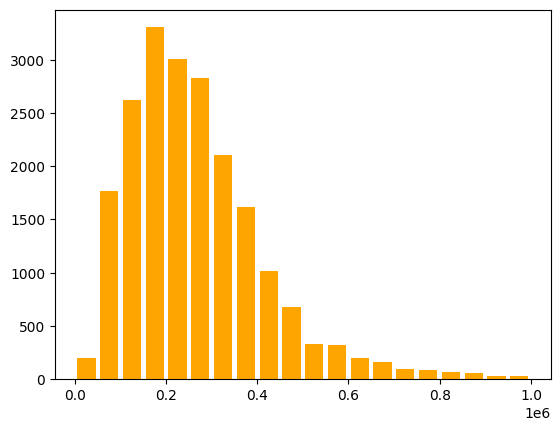

In [18]:
plt.hist(y_train[y_train["prix_bien"] < 1000000],  bins=20, color='orange', rwidth=0.8)

## Je repars sur le jeu de données total pour définir les intervals de prix sur l'ensemble du jeu de donnéees

In [81]:
y = pd.concat([y_train, y_test])

In [82]:
y

,prix_bien
idannonce,
ag681108-285757544,208300
ag680297-340567902,380000
hektor-girardi-pfastatt-2683,129000
orpi-1-054928E2CVGG,399000
ag671791-287402273,98000
...,...
immo-facile-35871425,100000
ag680254-273036872,210000
ag681158-373018354,72000


### Je découpe en 10 catégories définies à partir des quantiles

In [83]:
result = pd.qcut(y["prix_bien"], 10)

In [93]:
result

idannonce
ag681108-285757544              (176100.0, 209500.0]
ag680297-340567902              (369251.0, 457600.0]
hektor-girardi-pfastatt-2683    (105000.0, 145000.0]
orpi-1-054928E2CVGG             (369251.0, 457600.0]
ag671791-287402273              (1075.999, 105000.0]
                                        ...         
immo-facile-35871425            (1075.999, 105000.0]
ag680254-273036872              (209500.0, 242000.0]
ag681158-373018354              (1075.999, 105000.0]
apimo-5346718                   (277000.0, 318000.0]
iad-france-1009710              (242000.0, 277000.0]
Name: prix_bien, Length: 25696, dtype: category
Categories (10, interval[float64, right]): [(1075.999, 105000.0] < (105000.0, 145000.0] < (145000.0, 176100.0] < (176100.0, 209500.0] ... (277000.0, 318000.0] < (318000.0, 369251.0] < (369251.0, 457600.0] < (457600.0, 2730000.0]]

In [90]:
sorted(result.unique())

[Interval(1075.999, 105000.0, closed='right'),
 Interval(105000.0, 145000.0, closed='right'),
 Interval(145000.0, 176100.0, closed='right'),
 Interval(176100.0, 209500.0, closed='right'),
 Interval(209500.0, 242000.0, closed='right'),
 Interval(242000.0, 277000.0, closed='right'),
 Interval(277000.0, 318000.0, closed='right'),
 Interval(318000.0, 369251.0, closed='right'),
 Interval(369251.0, 457600.0, closed='right'),
 Interval(457600.0, 2730000.0, closed='right')]

In [91]:
conv_dict = dict()
conv_dict_inv = dict()
for i, value in enumerate(sorted(result.unique())):
    conv_dict[value] = i
    conv_dict_inv[i] = value

In [92]:
conv_dict

{Interval(1075.999, 105000.0, closed='right'): 0,
 Interval(105000.0, 145000.0, closed='right'): 1,
 Interval(145000.0, 176100.0, closed='right'): 2,
 Interval(176100.0, 209500.0, closed='right'): 3,
 Interval(209500.0, 242000.0, closed='right'): 4,
 Interval(242000.0, 277000.0, closed='right'): 5,
 Interval(277000.0, 318000.0, closed='right'): 6,
 Interval(318000.0, 369251.0, closed='right'): 7,
 Interval(369251.0, 457600.0, closed='right'): 8,
 Interval(457600.0, 2730000.0, closed='right'): 9}

In [94]:
result.apply(lambda x : conv_dict[x])

idannonce
ag681108-285757544              3
ag680297-340567902              8
hektor-girardi-pfastatt-2683    1
orpi-1-054928E2CVGG             8
ag671791-287402273              0
                               ..
immo-facile-35871425            0
ag680254-273036872              4
ag681158-373018354              0
apimo-5346718                   6
iad-france-1009710              5
Name: prix_bien, Length: 25696, dtype: category
Categories (10, int64): [0 < 1 < 2 < 3 ... 6 < 7 < 8 < 9]

In [95]:
y["prix_bien_converted"] = result.apply(lambda x : conv_dict[x])

In [96]:
y.shape

(25696, 2)

In [97]:
y_train = y.loc[y_train.index]

In [98]:
y_train

,prix_bien,prix_bien_converted
idannonce,,
ag681108-285757544,208300,3
ag680297-340567902,380000,8
hektor-girardi-pfastatt-2683,129000,1
orpi-1-054928E2CVGG,399000,8
ag671791-287402273,98000,0
...,...,...
ag440414-273408896,111000,1
ag681391-366397327,180000,3
orpi-1-054039E2F462,424800,8


In [99]:
y_test = y.loc[y_test.index]

In [100]:
y_test

,prix_bien,prix_bien_converted
idannonce,,
guy-hoquet-immo-facile-5974993,115400,1
ag680297-277810664,106500,1
orpi-1-054041E1OWKF,118250,1
guy-hoquet-immo-facile-6243822,76000,0
ag440414-293552741,390000,8
...,...,...
immo-facile-35871425,100000,0
ag680254-273036872,210000,4
ag681158-373018354,72000,0


## Classificateur random forrest

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [103]:
rfc = RandomForestClassifier(n_estimators=200, max_depth=10)

rfc.fit(X_train[selected],y_train["prix_bien_converted"])

y_pred_rfc = rfc.predict(X_test[selected])

accuracy_score(y_test["prix_bien_converted"], y_pred_rfc)

0.41837331772966646

## XBoost Classifier

In [106]:
from xgboost import XGBClassifier

xgbc_all = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgbc_all.fit(X_train[selected], y_train["prix_bien_converted"])

y_pred_xgb = xgbc_all.predict(X_test[selected])


accuracy_score(y_test["prix_bien_converted"], y_pred_xgb)

0.4289057928613224

## L'accuracy n'est pas bonne pour les 2 modèles. Passer sur une classification n'est pas une meilleure solution.